# Loading and labeling VIA images


In [ ]:
import cv2
import glob
import os
import numpy as np
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import random
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, recall_score, roc_auc_score, roc_curve, auc
import albumentations as A

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
drive.mount('/content/drive')

# Base path to your data folder
BASE_DATA_PATH = "/content/drive/MyDrive/cervical cancer data"

# VIA data paths
VIA_FOLDER = os.path.join(BASE_DATA_PATH, "via")

# IARC data paths
IARC_FOLDER = os.path.join(BASE_DATA_PATH, "IARCImageBankVIA")
IARC_METADATA_FILE = os.path.join(BASE_DATA_PATH, "IARCImageBankVIA", "Cases Meta data.xlsx")  # ← Capital M!

print(f"VIA folder: {VIA_FOLDER}")
print(f"IARC folder: {IARC_FOLDER}")
print(f"IARC metadata: {IARC_METADATA_FILE}")

Mounted at /content/drive
VIA folder: /content/drive/MyDrive/cervical cancer data/via
IARC folder: /content/drive/MyDrive/cervical cancer data/IARCImageBankVIA
IARC metadata: /content/drive/MyDrive/cervical cancer data/IARCImageBankVIA/Cases Meta data.xlsx


In [ ]:

print("via dataset load")
IMG_WIDTH = 224
IMG_HEIGHT = 224
# VIA label definitions
negative_cards = [3, 4, 6, 9, 12, 14, 15, 16, 19, 22, 26, 27, 28, 30, 31, 33, 34, 37, 40,
                  41, 44, 47, 48, 50, 51, 53, 54, 56, 57, 58, 60, 62, 66, 67, 71, 74, 75, 76,
                  79, 83, 84, 86, 88, 94, 95, 97, 99, 103, 104, 105, 106, 108, 109, 111, 114, 115]
positive_cards = [1, 2, 8, 10, 11, 13, 17, 18, 20, 21, 23, 24, 29, 32, 35, 36, 38, 39, 42,
                  43, 45, 46, 49, 52, 59, 61, 63, 64, 68, 69, 70, 72, 73, 77, 78, 80, 81, 82,
                  85, 87, 90, 91, 92, 93, 96, 98, 100, 101, 102, 107, 110, 112, 113, 116]
suspicious_cards = [5, 7, 25, 55, 65, 89]

def extract_via_card_number(filepath):
    """Extract card number from VIA filename (e.g., 'via_img_029.jpg' -> 29)"""
    filename = os.path.basename(filepath)
    # Try multiple naming patterns
    if 'via_img_' in filename:
        number_str = filename.split('via_img_')[-1].split('.')[0]
    elif filename.startswith('key_'):
        number_str = filename.split('key_')[-1].split('.')[0]
    else:
        number_str = filename.split('_')[-1].split('.')[0]
    return int(number_str)

def get_via_label(card_number):
    """Get label for VIA images: 0=negative, 1=positive, 2=suspicious"""
    if card_number in negative_cards:
        return 0
    elif card_number in positive_cards:
        return 1
    elif card_number in suspicious_cards:
        return 2
    else:
        return -1

# Load VIA images
via_image_paths = glob.glob(os.path.join(VIA_FOLDER, "*.jpg")) + \
                  glob.glob(os.path.join(VIA_FOLDER, "*.jpeg")) + \
                  glob.glob(os.path.join(VIA_FOLDER, "*.png"))

print(f"Found {len(via_image_paths)} image files in VIA folder")

images_via = []
labels_via = []
unlabeled_via = []

for path in via_image_paths:
    img = cv2.imread(path)
    if img is not None:
        img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        try:
            card_number = extract_via_card_number(path)
            label = get_via_label(card_number)
            if label != -1:
                images_via.append(img_resized)
                labels_via.append(label)
            else:
                unlabeled_via.append((path, card_number))
        except:
            print(f"Warning: Could not extract card number from {os.path.basename(path)}")

images_via = np.array(images_via)
labels_via = np.array(labels_via)

print(f"\nVIA images loaded: {len(images_via)}")
print(f"VIA label distribution:")
print(f"  NEGATIVE (0): {np.sum(labels_via == 0)}")
print(f"  POSITIVE (1): {np.sum(labels_via == 1)}")
print(f"  SUSPICIOUS (2): {np.sum(labels_via == 2)}")
print(f"  Unlabeled: {len(unlabeled_via)}")

via dataset load
Found 243 image files in VIA folder

VIA images loaded: 241
VIA label distribution:
  NEGATIVE (0): 112
  POSITIVE (1): 117
  SUSPICIOUS (2): 12
  Unlabeled: 0


In [ ]:

print("iarc dataset load")

# Load IARC metadata
try:
    # Try reading Excel file
    metadata_df = pd.read_excel(IARC_METADATA_FILE)
    print(f"Successfully loaded IARC metadata: {metadata_df.shape[0]} rows")
    print(f"\nMetadata columns: {list(metadata_df.columns)}")
except FileNotFoundError:
    print(f"ERROR: Metadata file not found at {IARC_METADATA_FILE}")
    print("Please check the file path and try again.")
    metadata_df = None
except Exception as e:
    print(f"ERROR loading metadata: {e}")
    metadata_df = None

# IARC label definitions based on case numbers (from your project updates)
iarc_negative_cases = list(range(1, 93))  # Cases 1-92
iarc_positive_cases = list(range(93, 167))  # Cases 93-166
iarc_suspicious_cases = list(range(167, 187))  # Cases 167-186

def extract_iarc_case_number(filepath):
    """Extract case number from IARC folder structure (e.g., 'Case 003' -> 3)"""
    folder = os.path.basename(os.path.dirname(filepath))
    if 'Case' in folder:
        number_str = folder.replace("Case", "").strip()
        return int(number_str)
    return -1

def get_iarc_label(case_number):
    """Get label for IARC images: 0=negative, 1=positive, 2=suspicious"""
    if case_number in iarc_negative_cases:
        return 0
    elif case_number in iarc_positive_cases:
        return 1
    elif case_number in iarc_suspicious_cases:
        return 2
    else:
        return -1

# Load IARC images (typically one representative image per case)
# Common patterns: AFC1.jpg, image1.jpg, *1.jpg
iarc_image_paths = []
for case_num in range(1, 187):  # Cases 001 to 186
    case_folder = os.path.join(IARC_FOLDER, f"Case {case_num:03d}")
    if os.path.exists(case_folder):
        # Try multiple common patterns for the first/representative image
        # Pattern 1: Files ending with 1.jpg (e.g., AFC1.jpg, image1.jpg)
        pattern_paths = glob.glob(os.path.join(case_folder, "*1.jpg")) + \
                       glob.glob(os.path.join(case_folder, "*1.jpeg")) + \
                       glob.glob(os.path.join(case_folder, "*1.png"))

        # If no images found with pattern 1, try getting the first alphabetically
        if not pattern_paths:
            all_images = glob.glob(os.path.join(case_folder, "*.jpg")) + \
                        glob.glob(os.path.join(case_folder, "*.jpeg")) + \
                        glob.glob(os.path.join(case_folder, "*.png"))
            if all_images:
                pattern_paths = [sorted(all_images)[0]]  # Take first image alphabetically

        iarc_image_paths.extend(pattern_paths)

print(f"Found {len(iarc_image_paths)} IARC images (one per case folder)")

images_iarc = []
labels_iarc = []
case_numbers_iarc = []
unlabeled_iarc = []

for path in iarc_image_paths:
    img = cv2.imread(path)
    if img is not None:
        img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        case_number = extract_iarc_case_number(path)
        label = get_iarc_label(case_number)

        if label != -1:
            images_iarc.append(img_resized)
            labels_iarc.append(label)
            case_numbers_iarc.append(case_number)
        else:
            unlabeled_iarc.append((path, case_number))

images_iarc = np.array(images_iarc)
labels_iarc = np.array(labels_iarc)
case_numbers_iarc = np.array(case_numbers_iarc)

print(f"\nIARC images loaded: {len(images_iarc)}")
print(f"IARC label distribution:")
print(f"  NEGATIVE (0): {np.sum(labels_iarc == 0)}")
print(f"  POSITIVE (1): {np.sum(labels_iarc == 1)}")
print(f"  SUSPICIOUS (2): {np.sum(labels_iarc == 2)}")
print(f"  Unlabeled: {len(unlabeled_iarc)}")


iarc dataset load
Successfully loaded IARC metadata: 186 rows

Metadata columns: ['CaseNumber', 'CaseID', 'SCJ', 'SCJ Location', 'Acitowhite area', 'Acitowhite area color', 'Acitowhite area margin', 'Acitowhite area surface', 'Acitowhite area location', 'Acitowhite area size', 'VIA', 'Eligibility for ablative treatment', 'Histology findings']
Found 181 IARC images (one per case folder)

IARC images loaded: 181
IARC label distribution:
  NEGATIVE (0): 89
  POSITIVE (1): 72
  SUSPICIOUS (2): 20
  Unlabeled: 0


In [ ]:

print("combine via + iarc data")


# Use ALL VIA images + 20 samples from each IARC class
#adds 60 IARC images to your existing ~115 VIA images

# Find indices for each class in IARC data
idx_iarc_neg = np.where(labels_iarc == 0)[0]
idx_iarc_pos = np.where(labels_iarc == 1)[0]
idx_iarc_susp = np.where(labels_iarc == 2)[0]

print(f"\nIARC images available per class:")
print(f"  NEGATIVE (0): {len(idx_iarc_neg)}")
print(f"  POSITIVE (1): {len(idx_iarc_pos)}")
print(f"  SUSPICIOUS (2): {len(idx_iarc_susp)}")

# Sample 20 from each IARC class (or all if fewer than 20)
n_samples_per_class = 20
sample_iarc_neg = random.sample(list(idx_iarc_neg), min(n_samples_per_class, len(idx_iarc_neg)))
sample_iarc_pos = random.sample(list(idx_iarc_pos), min(n_samples_per_class, len(idx_iarc_pos)))
sample_iarc_susp = list(idx_iarc_susp)  # Take ALL suspicious (typically ~20)

selected_iarc_idx = sample_iarc_neg + sample_iarc_pos + sample_iarc_susp

print(f"\nSelected IARC images:")
print(f"  NEGATIVE: {len(sample_iarc_neg)}")
print(f"  POSITIVE: {len(sample_iarc_pos)}")
print(f"  SUSPICIOUS: {len(sample_iarc_susp)}")
print(f"  TOTAL IARC SELECTED: {len(selected_iarc_idx)}")

# Combine VIA (all) + IARC (sampled)
X_via_all = images_via
y_via_all = labels_via

X_iarc_selected = images_iarc[selected_iarc_idx]
y_iarc_selected = labels_iarc[selected_iarc_idx]

# Final combined dataset
images_combined = np.concatenate([X_via_all, X_iarc_selected], axis=0)
labels_combined = np.concatenate([y_via_all, y_iarc_selected], axis=0)

print(f"\nFINAL COMBINED DATASET:")
print(f"  Total images: {len(images_combined)}")
print(f"  Class distribution:")
print(f"    NEGATIVE (0): {np.sum(labels_combined == 0)}")
print(f"    POSITIVE (1): {np.sum(labels_combined == 1)}")
print(f"    SUSPICIOUS (2): {np.sum(labels_combined == 2)}")


combine via + iarc data

IARC images available per class:
  NEGATIVE (0): 89
  POSITIVE (1): 72
  SUSPICIOUS (2): 20

Selected IARC images:
  NEGATIVE: 20
  POSITIVE: 20
  SUSPICIOUS: 20
  TOTAL IARC SELECTED: 60

FINAL COMBINED DATASET:
  Total images: 301
  Class distribution:
    NEGATIVE (0): 132
    POSITIVE (1): 137
    SUSPICIOUS (2): 32


visualize sample imgs
Sample images saved to /content/sample_images.png


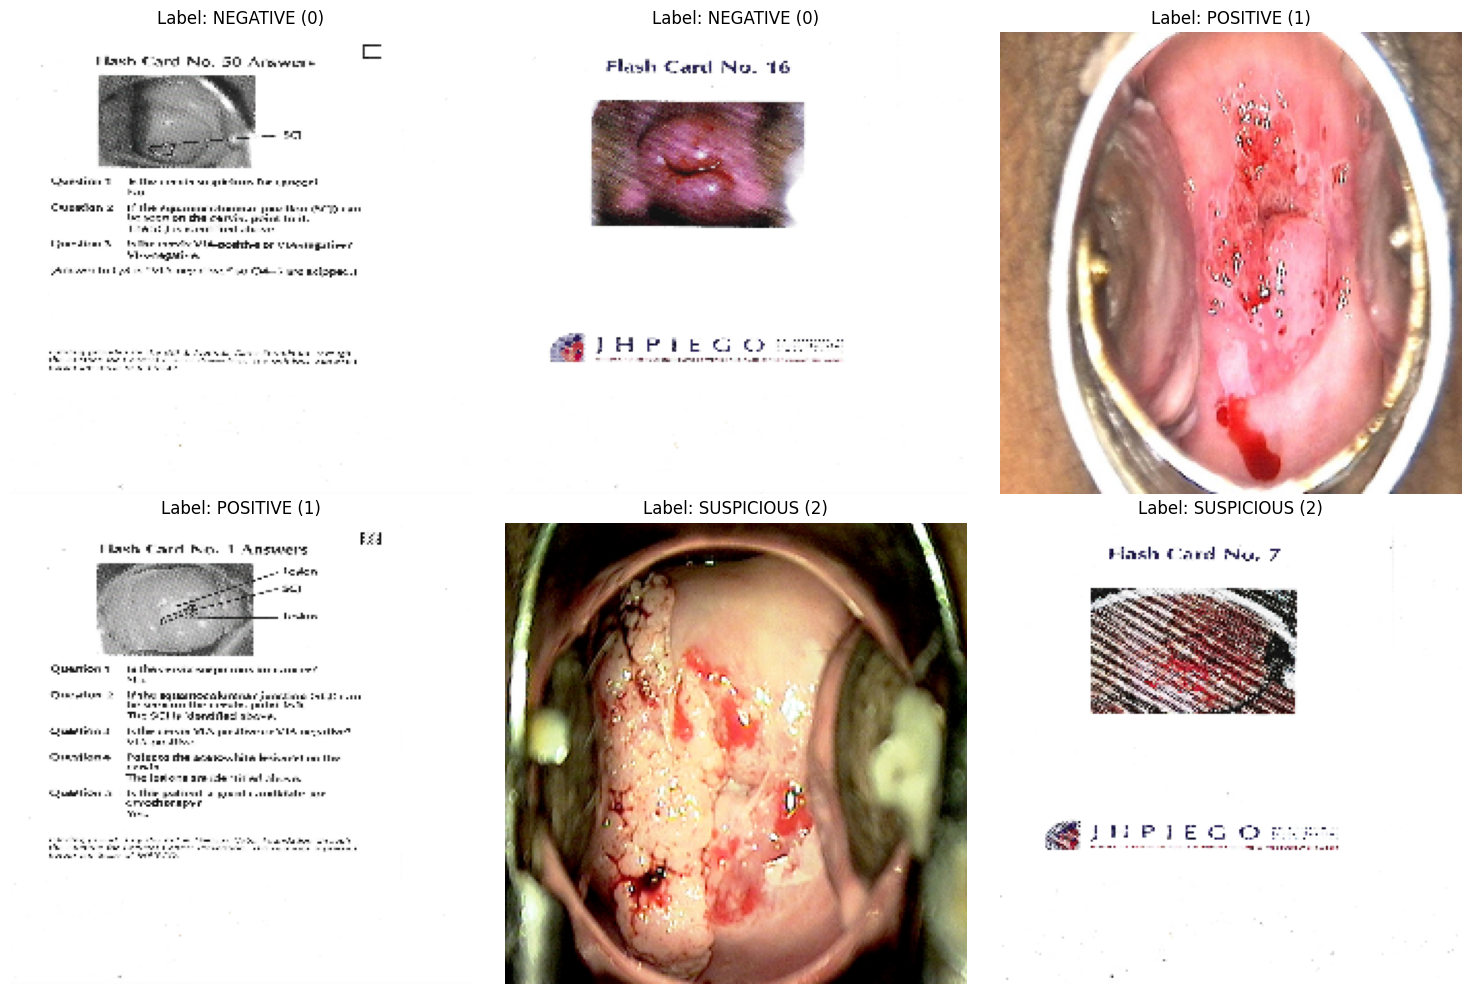

In [ ]:

print("visualize sample imgs")


# Plot sample images from each class
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
label_names = {0: 'NEGATIVE', 1: 'POSITIVE', 2: 'SUSPICIOUS'}

sample_indices = []
for label in [0, 1, 2]:
    class_indices = np.where(labels_combined == label)[0]
    if len(class_indices) >= 2:
        sample_indices.extend(random.sample(list(class_indices), 2))

for i, idx in enumerate(sample_indices[:6]):
    img_rgb = cv2.cvtColor(images_combined[idx], cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(f'Label: {label_names[labels_combined[idx]]} ({labels_combined[idx]})')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150, bbox_inches='tight')
print("Sample images saved to /content/sample_images.png")
plt.show()


# Create Train/Test Split

In [ ]:

print("create train/test split")

# Convert BGR to RGB for processing
images_rgb = images_combined[..., ::-1].copy()

def stratified_70_15_15(X, y, seed=42):
    """Create stratified 70/15/15 split"""
    # First split: train vs temp (val+test)
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, temp_idx = next(sss1.split(np.zeros(len(y)), y))

    # Second split: val vs test from temp
    y_temp = y[temp_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed+1)
    val_rel, test_rel = next(sss2.split(np.zeros(len(y_temp)), y_temp))

    val_idx = temp_idx[val_rel]
    test_idx = temp_idx[test_rel]

    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_70_15_15(images_rgb, labels_combined, SEED)

print(f"Split sizes: Train={len(train_idx)}, Val={len(val_idx)}, Test={len(test_idx)}")
print(f"Train class counts: {dict(zip([0,1,2], [int((labels_combined[train_idx]==c).sum()) for c in [0,1,2]]))}")
print(f"Val class counts:   {dict(zip([0,1,2], [int((labels_combined[val_idx]==c).sum()) for c in [0,1,2]]))}")
print(f"Test class counts:  {dict(zip([0,1,2], [int((labels_combined[test_idx]==c).sum()) for c in [0,1,2]]))}")


create train/test split
Split sizes: Train=210, Val=45, Test=46
Train class counts: {0: 92, 1: 96, 2: 22}
Val class counts:   {0: 20, 1: 20, 2: 5}
Test class counts:  {0: 20, 1: 21, 2: 5}


# Data Augmentation

In [ ]:

print("data augmentation")

# Geometry augmentation (subtle, same for all classes)
geo = A.Affine(
    rotate=(-7, 7),
    translate_percent={"x":(-0.03, 0.03), "y":(-0.03, 0.03)},
    scale=(0.95, 1.05),
    shear={"x": 0, "y": 0},
    p=0.5,
)

# Photometric augmentation (base for negative/positive)
photo_base = [
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=1.0),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=1.0),
    ], p=0.7),
    A.RandomGamma(gamma_limit=(90,110), p=0.5),
    A.ColorJitter(hue=0.02, saturation=0.08, p=0.3),
    A.GaussianBlur(blur_limit=(3,5), sigma_limit=(0,0.8), p=0.2),
    A.GaussNoise(var_limit=(2.0, 8.0), p=0.2),
    A.ImageCompression(quality_lower=80, quality_upper=95, p=0.3),
    A.CoarseDropout(num_holes=1, max_h_size=32, max_w_size=32, fill_value=0, p=0.2),
]

# Stronger augmentation for minority "suspicious" class
photo_tail = [
    A.RandomBrightnessContrast(brightness_limit=0.22, contrast_limit=0.22, p=0.8),
    A.RandomGamma(gamma_limit=(85,115), p=0.6),
    A.ColorJitter(hue=0.025, saturation=0.10, p=0.35),
    A.GaussianBlur(blur_limit=(5,7), sigma_limit=(0,1.0), p=0.25),
    A.GaussNoise(var_limit=(3.0, 10.0), p=0.25),
    A.ImageCompression(quality_lower=75, quality_upper=95, p=0.35),
    A.CoarseDropout(num_holes=1, max_h_size=32, max_w_size=32, fill_value=0, p=0.2),
]

TARGET_SIZE = IMG_HEIGHT

def build_transform(label: int):
    """Build augmentation pipeline based on class label"""
    photo = photo_tail if label == 2 else photo_base
    return A.Compose([
        A.LongestMaxSize(max_size=TARGET_SIZE),
        A.PadIfNeeded(TARGET_SIZE, TARGET_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0),
        geo,
        *photo,
    ])

# Augmentation multipliers per class
AUG_MULT = {0: 2, 1: 2, 2: 8}  # Oversample suspicious class more

def augment_split(imgs, labs, idxs, mult_map):
    """Apply augmentation to training data"""
    aug_imgs, aug_labs = [], []
    for i in idxs:
        img = imgs[i]
        lab = int(labs[i])
        k = int(mult_map.get(lab, 1))
        tf = build_transform(lab)
        for j in range(k):
            out = tf(image=img)
            aug_imgs.append(out["image"])
            aug_labs.append(lab)
    return np.stack(aug_imgs, axis=0), np.array(aug_labs, dtype=np.int64)

# Augment training data
print("Augmenting training data...")
aug_train_X, aug_train_y = augment_split(images_rgb, labels_combined, train_idx, AUG_MULT)

# Combine original + augmented for training
train_X = np.concatenate([images_rgb[train_idx], aug_train_X], axis=0)
train_y = np.concatenate([labels_combined[train_idx], aug_train_y], axis=0)

# Validation and test remain unchanged
val_X, val_y = images_rgb[val_idx], labels_combined[val_idx]
test_X, test_y = images_rgb[test_idx], labels_combined[test_idx]

print(f"\nFinal augmented dataset shapes:")
print(f"  Train: {train_X.shape}, labels: {train_y.shape}")
print(f"  Train class counts: {dict(zip([0,1,2], [int((train_y==c).sum()) for c in [0,1,2]]))}")
print(f"  Val:   {val_X.shape}, labels: {val_y.shape}")
print(f"  Test:  {test_X.shape}, labels: {test_y.shape}")


data augmentation
Augmenting training data...


/tmp/ipython-input-313587578.py:21: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(2.0, 8.0), p=0.2),
/tmp/ipython-input-313587578.py:22: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=80, quality_upper=95, p=0.3),
/tmp/ipython-input-313587578.py:23: UserWarning: Argument(s) 'num_holes, max_h_size, max_w_size, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(num_holes=1, max_h_size=32, max_w_size=32, fill_value=0, p=0.2),
/tmp/ipython-input-313587578.py:32: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(3.0, 10.0), p=0.25),
/tmp/ipython-input-313587578.py:33: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, quality_upper=95, p=0.35),
/tmp/ipython-input-313587578.py:34: UserWarni


Final augmented dataset shapes:
  Train: (762, 224, 224, 3), labels: (762,)
  Train class counts: {0: 276, 1: 288, 2: 198}
  Val:   (45, 224, 224, 3), labels: (45,)
  Test:  (46, 224, 224, 3), labels: (46,)


In [ ]:

print("pytorch datasets")

class NumpyImageDataset(Dataset):
    """Custom dataset for numpy arrays"""
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx].astype(np.uint8)
        if self.transform:
            img = self.transform(img)
        label = int(self.y[idx])
        return img, label

# ImageNet normalization
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

# Create datasets
train_ds = NumpyImageDataset(train_X, train_y, transform=base_transform)
val_ds = NumpyImageDataset(val_X, val_y, transform=base_transform)
test_ds = NumpyImageDataset(test_X, test_y, transform=base_transform)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"DataLoaders created with batch_size={batch_size}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

pytorch datasets
DataLoaders created with batch_size=32
  Train batches: 24
  Val batches: 2
  Test batches: 2


# Load Model and Train

In [ ]:


# Load pretrained MobileNetV3-Large
weights = MobileNet_V3_Large_Weights.IMAGENET1K_V1
model = mobilenet_v3_large(weights=weights)

# Replace final classifier with 3-class head
num_ftrs = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(num_ftrs, 3)
model = model.to(device)

print(f"Model: MobileNetV3-Large")
print(f"Output classes: 3 (NEGATIVE, POSITIVE, SUSPICIOUS)")
print(f"Device: {device}")

def run_epoch(model, loader, criterion, optimizer=None):
    """Run one epoch of training or evaluation"""
    if optimizer is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if optimizer is not None:
            optimizer.zero_grad()

        with torch.set_grad_enabled(optimizer is not None):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if optimizer is not None:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 113MB/s]


Model: MobileNetV3-Large
Output classes: 3 (NEGATIVE, POSITIVE, SUSPICIOUS)
Device: cpu


In [ ]:


print("classifier head training")

# Freeze all parameters
for p in model.parameters():
    p.requires_grad = False

# Unfreeze only final classifier layer
for p in model.classifier[-1].parameters():
    p.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer_head = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)

epochs_head = 10
best_val_acc_head = 0.0

print(f"Training for {epochs_head} epochs...")
for epoch in range(1, epochs_head + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer_head)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    if val_acc > best_val_acc_head:
        best_val_acc_head = val_acc
        torch.save(model.state_dict(), "/content/best_mobilenet_head_only.pt")
        print(f"  ✓ Saved best model (val_acc={val_acc:.4f})")

    print(f"[Epoch {epoch}/{epochs_head}] "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

print(f"\nPhase 1 complete. Best validation accuracy: {best_val_acc_head:.4f}")


classifier head training
Training for 10 epochs...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  ✓ Saved best model (val_acc=0.5556)
[Epoch 1/10] train_loss=0.9737 train_acc=0.4934 | val_loss=0.9039 val_acc=0.5556
[Epoch 2/10] train_loss=0.7320 train_acc=0.7073 | val_loss=0.8078 val_acc=0.5556
  ✓ Saved best model (val_acc=0.6667)
[Epoch 3/10] train_loss=0.6166 train_acc=0.7546 | val_loss=0.7865 val_acc=0.6667
[Epoch 4/10] train_loss=0.5562 train_acc=0.7769 | val_loss=0.7388 val_acc=0.6667
[Epoch 5/10] train_loss=0.4956 train_acc=0.8307 | val_loss=0.7117 val_acc=0.6667
  ✓ Saved best model (val_acc=0.7333)
[Epoch 6/10] train_loss=0.4763 train_acc=0.8110 | val_loss=0.6645 val_acc=0.7333
[Epoch 7/10] train_loss=0.4425 train_acc=0.8412 | val_loss=0.6765 val_acc=0.6889
[Epoch 8/10] train_loss=0.4091 train_acc=0.8661 | val_loss=0.7075 val_acc=0.6000
[Epoch 9/10] train_loss=0.4119 train_acc=0.8648 | val_loss=0.6647 val_acc=0.6444
[Epoch 10/10] train_loss=0.3800 train_acc=0.8675 | val_loss=0.6761 val_acc=0.6444

Phase 1 complete. Best validation accuracy: 0.7333


In [ ]:


print("fine tune upper blocks")

# Reload best head-only weights
model.load_state_dict(torch.load("/content/best_mobilenet_head_only.pt", map_location=device))

# Unfreeze classifier + last 3 feature blocks
for p in model.classifier.parameters():
    p.requires_grad = True

for p in model.features[-3:].parameters():
    p.requires_grad = True

optimizer_ft = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,  # Lower learning rate for fine-tuning
    weight_decay=1e-4,
)

epochs_ft = 15
best_val_acc_ft = 0.0

print(f"Fine-tuning for {epochs_ft} epochs...")
for epoch in range(1, epochs_ft + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer_ft)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    if val_acc > best_val_acc_ft:
        best_val_acc_ft = val_acc
        torch.save(model.state_dict(), "/content/best_mobilenet_finetuned.pt")
        print(f"  ✓ Saved best model (val_acc={val_acc:.4f})")

    print(f"[Epoch {epoch}/{epochs_ft}] "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

print(f"\nPhase 2 complete. Best validation accuracy: {best_val_acc_ft:.4f}")


fine tune upper blocks
Fine-tuning for 15 epochs...
  ✓ Saved best model (val_acc=0.6444)
[Epoch 1/15] train_loss=0.4208 train_acc=0.8491 | val_loss=0.6506 val_acc=0.6444
  ✓ Saved best model (val_acc=0.6889)
[Epoch 2/15] train_loss=0.2890 train_acc=0.9252 | val_loss=0.6130 val_acc=0.6889
  ✓ Saved best model (val_acc=0.7333)
[Epoch 3/15] train_loss=0.1979 train_acc=0.9449 | val_loss=0.5962 val_acc=0.7333
[Epoch 4/15] train_loss=0.1769 train_acc=0.9541 | val_loss=0.5870 val_acc=0.7333
[Epoch 5/15] train_loss=0.1386 train_acc=0.9593 | val_loss=0.5772 val_acc=0.7111
[Epoch 6/15] train_loss=0.1047 train_acc=0.9646 | val_loss=0.6158 val_acc=0.7333
[Epoch 7/15] train_loss=0.0694 train_acc=0.9869 | val_loss=0.5741 val_acc=0.6889
[Epoch 8/15] train_loss=0.0720 train_acc=0.9829 | val_loss=0.8714 val_acc=0.6222
[Epoch 9/15] train_loss=0.0519 train_acc=0.9856 | val_loss=0.9396 val_acc=0.6444
[Epoch 10/15] train_loss=0.0275 train_acc=0.9948 | val_loss=0.7824 val_acc=0.7111
[Epoch 11/15] train_los

#Model Evaluation

In [ ]:

print("test eval")

# Load best model
model.load_state_dict(torch.load("/content/best_mobilenet_finetuned.pt", map_location=device))
test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer=None)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


test eval


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Test Loss: 0.4033
Test Accuracy: 0.8478


In [ ]:


model.eval()
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_labels = np.concatenate(all_labels)
all_preds = np.concatenate(all_preds)
all_probs = np.concatenate(all_probs)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

# Sensitivity (recall) per class
sensitivity_per_class = np.diag(cm) / cm.sum(axis=1)
print("\nSensitivity (Recall) per class:")
class_names = ['NEGATIVE', 'POSITIVE', 'SUSPICIOUS']
for i, (name, s) in enumerate(zip(class_names, sensitivity_per_class)):
    print(f"  {name} (class {i}): {s:.4f}")

# Macro and weighted recall
recall_macro = recall_score(all_labels, all_preds, average='macro')
recall_weighted = recall_score(all_labels, all_preds, average='weighted')
print(f"\nMacro Recall: {recall_macro:.4f}")
print(f"Weighted Recall: {recall_weighted:.4f}")

# Specificity per class
specificity_per_class = []
num_classes = cm.shape[0]
total = cm.sum()

for i in range(num_classes):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = total - (TP + FP + FN)
    spec = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    specificity_per_class.append(spec)

print("\nSpecificity per class:")
for i, (name, sp) in enumerate(zip(class_names, specificity_per_class)):
    print(f"  {name} (class {i}): {sp:.4f}")

# AUC
try:
    auc_macro_ovr = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    auc_weighted_ovr = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
    print(f"\nAUC (One-vs-Rest, macro): {auc_macro_ovr:.4f}")
    print(f"AUC (One-vs-Rest, weighted): {auc_weighted_ovr:.4f}")
except ValueError as e:
    print(f"\nAUC could not be computed: {e}")


Confusion Matrix:
[[17  3  0]
 [ 3 18  0]
 [ 0  1  4]]

Sensitivity (Recall) per class:
  NEGATIVE (class 0): 0.8500
  POSITIVE (class 1): 0.8571
  SUSPICIOUS (class 2): 0.8000

Macro Recall: 0.8357
Weighted Recall: 0.8478

Specificity per class:
  NEGATIVE (class 0): 0.8846
  POSITIVE (class 1): 0.8400
  SUSPICIOUS (class 2): 1.0000

AUC (One-vs-Rest, macro): 0.9459
AUC (One-vs-Rest, weighted): 0.9389


Saved: /content/confusion_matrix_counts.png


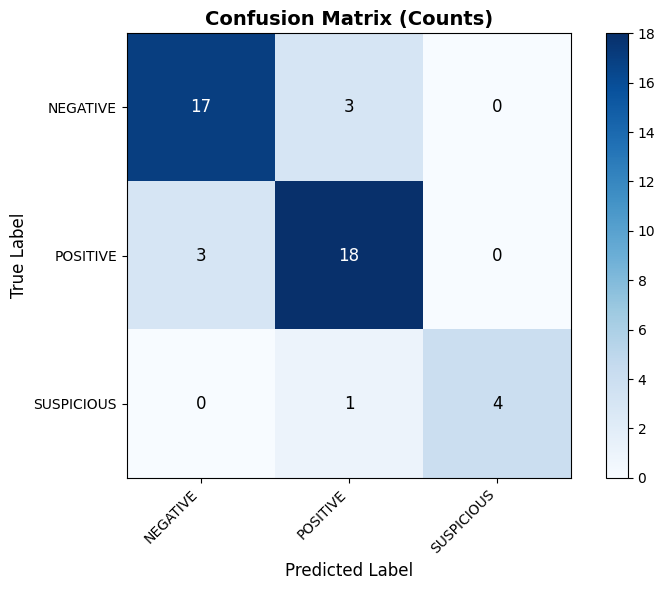

Saved: /content/confusion_matrix_normalized.png


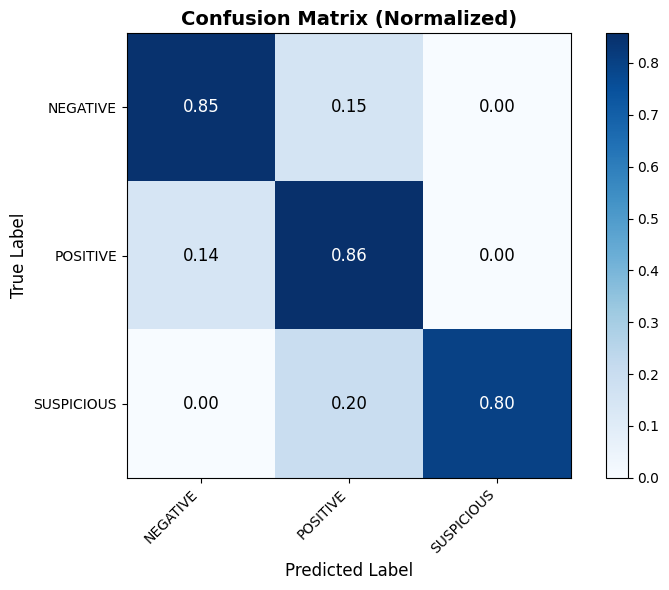

In [ ]:


# Confusion matrix (counts)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title("Confusion Matrix (Counts)", fontsize=14, fontweight='bold')
ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for i in range(num_classes):
    for j in range(num_classes):
        text = ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)

ax.set_ylabel("True Label", fontsize=12)
ax.set_xlabel("Predicted Label", fontsize=12)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('/content/confusion_matrix_counts.png', dpi=150, bbox_inches='tight')
print("Saved: /content/confusion_matrix_counts.png")
plt.show()

# Confusion matrix (normalized)
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
ax.set_title("Confusion Matrix (Normalized)", fontsize=14, fontweight='bold')
ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for i in range(num_classes):
    for j in range(num_classes):
        text = ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center",
                      color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=12)

ax.set_ylabel("True Label", fontsize=12)
ax.set_xlabel("Predicted Label", fontsize=12)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('/content/confusion_matrix_normalized.png', dpi=150, bbox_inches='tight')
print("Saved: /content/confusion_matrix_normalized.png")
plt.show()


Saved: /content/roc_curves.png


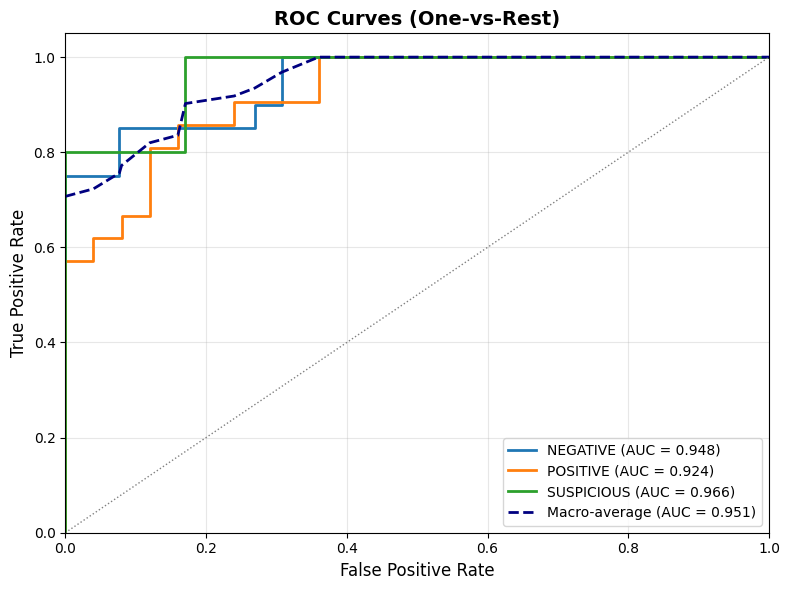

In [ ]:

# ROC curves (one-vs-rest)
fpr, tpr, roc_auc = {}, {}, {}
valid_classes = []

for i in range(num_classes):
    y_true = (all_labels == i).astype(int)
    if y_true.max() == 0 or y_true.min() == 1:
        continue
    y_score = all_probs[:, i]
    fpr[i], tpr[i], _ = roc_curve(y_true, y_score)
    roc_auc[i] = auc(fpr[i], tpr[i])
    valid_classes.append(i)

plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i in valid_classes:
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

if valid_classes:
    all_fpr = np.unique(np.concatenate([fpr[i] for i in valid_classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in valid_classes:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(valid_classes)
    macro_auc = auc(all_fpr, mean_tpr)
    plt.plot(all_fpr, mean_tpr, linestyle="--", color='navy', lw=2,
             label=f"Macro-average (AUC = {macro_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle=":", color='gray', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves (One-vs-Rest)", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=150, bbox_inches='tight')
print("Saved: /content/roc_curves.png")
plt.show()


In [ ]:


# Create results summary
results_summary = f"""
results summary {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}


Total images: {len(images_combined)}
- VIA images: {len(images_via)}
- IARC images (selected): {len(selected_iarc_idx)}

combined class distribution:
- NEGATIVE (0): {np.sum(labels_combined == 0)}
- POSITIVE (1): {np.sum(labels_combined == 1)}
- SUSPICIOUS (2): {np.sum(labels_combined == 2)}

Train/Val/Test split: {len(train_idx)}/{len(val_idx)}/{len(test_idx)}

After augmentation:
- Train samples: {len(train_y)}
- Val samples: {len(val_y)}
- Test samples: {len(test_y)}

MODEL INFORMATION:
Architecture: MobileNetV3-Large (pretrained on ImageNet)
Output classes: 3 (NEGATIVE, POSITIVE, SUSPICIOUS)
Training strategy: Two-phase (head-only, then fine-tuning)

PERFORMANCE METRICS:
Test Accuracy: {test_acc:.4f}
Test Loss: {test_loss:.4f}

Sensitivity (Recall) per class:
- NEGATIVE: {sensitivity_per_class[0]:.4f}
- POSITIVE: {sensitivity_per_class[1]:.4f}
- SUSPICIOUS: {sensitivity_per_class[2]:.4f}

Specificity per class:
- NEGATIVE: {specificity_per_class[0]:.4f}
- POSITIVE: {specificity_per_class[1]:.4f}
- SUSPICIOUS: {specificity_per_class[2]:.4f}

Macro Recall: {recall_macro:.4f}
Weighted Recall: {recall_weighted:.4f}

Confusion Matrix (counts):
{cm}

Confusion Matrix (normalized):
{cm_norm}

FILES SAVED:
- Model weights: /content/best_mobilenet_finetuned.pt
- Sample images: /content/sample_images.png
- Confusion matrix (counts): /content/confusion_matrix_counts.png
- Confusion matrix (normalized): /content/confusion_matrix_normalized.png
- ROC curves: /content/roc_curves.png
- This summary: /content/results_summary.txt

"""

with open('/content/results_summary.txt', 'w') as f:
    f.write(results_summary)

print(results_summary)
print("\nResults summary saved to: /content/results_summary.txt")




results summary 2025-11-18 21:07:17


Total images: 301
- VIA images: 241
- IARC images (selected): 60

combined class distribution:
- NEGATIVE (0): 132
- POSITIVE (1): 137
- SUSPICIOUS (2): 32

Train/Val/Test split: 210/45/46

After augmentation:
- Train samples: 762
- Val samples: 45
- Test samples: 46

MODEL INFORMATION:
Architecture: MobileNetV3-Large (pretrained on ImageNet)
Output classes: 3 (NEGATIVE, POSITIVE, SUSPICIOUS)
Training strategy: Two-phase (head-only, then fine-tuning)

PERFORMANCE METRICS:
Test Accuracy: 0.8478
Test Loss: 0.4033

Sensitivity (Recall) per class:
- NEGATIVE: 0.8500
- POSITIVE: 0.8571
- SUSPICIOUS: 0.8000

Specificity per class:
- NEGATIVE: 0.8846
- POSITIVE: 0.8400
- SUSPICIOUS: 1.0000

Macro Recall: 0.8357
Weighted Recall: 0.8478

Confusion Matrix (counts):
[[17  3  0]
 [ 3 18  0]
 [ 0  1  4]]

Confusion Matrix (normalized):
[[0.85       0.15       0.        ]
 [0.14285714 0.85714286 0.        ]
 [0.         0.2        0.8       ]]

FILES SAVED:
- M